# L'Embedding dans le Transformer

Dans ce notebook, nous allons explorer la **première brique** du Transformer : la couche d'embedding.

Avant qu'un réseau de neurones puisse traiter du texte, il faut répondre à une question fondamentale :

> **Comment représenter des mots sous forme de nombres ?**

La couche d'embedding est la réponse à cette question. Elle est composée de **deux parties** :

1. **Token Embedding** — convertir chaque mot en un vecteur de nombres réels
2. **Positional Encoding** — injecter l'information sur la position de chaque mot dans la phrase

---

**Architecture générale du Transformer (vue simplifiée) :**

```
Texte brut  →  [Token Embedding]  +  [Positional Encoding]  →  Représentation vectorielle
                      ↓                        ↓
               "chat" → [0.2, -0.5, ...]   pos=1 → [0.0, 1.0, ...]
                              ↓
                    Somme des deux vecteurs
                              ↓
              Entrée des couches d'attention
```

## 1. Pourquoi a-t-on besoin d'embeddings ?

Un réseau de neurones ne comprend que les nombres. Impossible de lui donner directement le mot `"chat"`.  
La première idée naïve serait d'utiliser un **encodage one-hot** :

```
Vocabulaire : ["le", "chat", "mange", "poisson", "dort"]

"le"      → [1, 0, 0, 0, 0]
"chat"    → [0, 1, 0, 0, 0]
"mange"   → [0, 0, 1, 0, 0]
"poisson" → [0, 0, 0, 1, 0]
"dort"    → [0, 0, 0, 0, 1]
```

**Problèmes du one-hot :**
- Vecteurs très **creux** (sparse) — si le vocabulaire contient 50 000 mots, chaque vecteur a 49 999 zéros
- **Aucune information sémantique** — `"chat"` et `"chien"` sont aussi éloignés que `"chat"` et `"voiture"`
- La distance entre tous les mots est identique

**Solution : l'embedding**  
On apprend une représentation **dense** dans un espace de dimension `d_model` (ex: 512), tel que des mots sémantiquement proches aient des vecteurs proches dans cet espace.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Pour la reproductibilité
torch.manual_seed(42)
np.random.seed(42)

Librairies importées avec succès !
Version de PyTorch : 2.11.0+cpu


## 2. Token Embedding

### 2.1 Concept mathématique

Un embedding est essentiellement une **table de correspondance** (lookup table) :

- On associe chaque mot du vocabulaire à un **indice entier** : `mot → id`
- On crée une matrice **E** de taille `(V, d_model)` où :
  - `V` = taille du vocabulaire
  - `d_model` = dimension de l'espace d'embedding
- Pour obtenir l'embedding d'un mot, on fait simplement : `E[id_du_mot]`

```
Matrice E (V × d_model) :

          dim_0   dim_1   dim_2   dim_3
"le"   [  0.42,  -0.13,   0.87,   0.05 ]   ← ligne 0
"chat" [ -0.21,   0.94,  -0.33,   0.71 ]   ← ligne 1
"mange"[  0.15,   0.02,   0.60,  -0.48 ]   ← ligne 2
  ...

"chat" → id=1 → E[1] = [-0.21, 0.94, -0.33, 0.71]
```

Cette matrice **E est apprise** pendant l'entraînement par rétropropagation, tout comme les poids d'un réseau de neurones classique.

### 2.2 Implémentation manuelle

In [2]:
# --- Étape 1 : Définir un vocabulaire simple ---
vocab = {
    "le":      0,
    "chat":    1,
    "mange":   2,
    "poisson": 3,
    "dort":    4,
    "<PAD>":   5,   # token de rembourrage (padding)
}

V       = len(vocab)   # taille du vocabulaire
d_model = 4            # dimension de l'embedding (petit pour l'exemple)

print(f"Vocabulaire : {vocab}")
print(f"Taille du vocabulaire V = {V}")
print(f"Dimension d_model = {d_model}")

Vocabulaire : {'le': 0, 'chat': 1, 'mange': 2, 'poisson': 3, 'dort': 4, '<PAD>': 5}
Taille du vocabulaire V = 6
Dimension d_model = 4


In [3]:
# --- Étape 2 : Tokenisation d'une phrase ---
phrase = ["le", "chat", "mange"]
indices = [vocab[mot] for mot in phrase]

print(f"Phrase     : {phrase}")
print(f"Indices    : {indices}")

Phrase     : ['le', 'chat', 'mange']
Indices    : [0, 1, 2]


In [4]:
# --- Étape 3 : La matrice d'embedding E (initialisée aléatoirement) ---
# En pratique, ces valeurs sont apprises par le réseau
E = torch.randn(V, d_model)

print("Matrice d'embedding E (V × d_model) :")
print(E)
print(f"\nShape de E : {E.shape}   →   ({V} mots, {d_model} dimensions)")

Matrice d'embedding E (V × d_model) :
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055],
        [ 0.6784, -1.2345, -0.0431, -1.6047],
        [ 0.3559, -0.6866, -0.4934,  0.2415],
        [-1.1109,  0.0915, -2.3169, -0.2168],
        [-0.3097, -0.3957,  0.8034, -0.6216],
        [-0.5920, -0.0631, -0.8286,  0.3309]])

Shape de E : torch.Size([6, 4])   →   (6 mots, 4 dimensions)


In [5]:
# --- Étape 4 : Le lookup — extraire les vecteurs des mots de notre phrase ---
indices_tensor = torch.tensor(indices)
embeddings_manuels = E[indices_tensor]   # simple indexation de la matrice

print("Embeddings extraits pour la phrase :\n")
for mot, emb in zip(phrase, embeddings_manuels):
    print(f"  '{mot}' → {emb.tolist()}")

print(f"\nShape de la sortie : {embeddings_manuels.shape}")
print(f"  → (seq_len={len(phrase)}, d_model={d_model})")

Embeddings extraits pour la phrase :

  'le' → [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232]
  'chat' → [0.6784183979034424, -1.2345448732376099, -0.04306747764348984, -1.6046669483184814]
  'mange' → [0.3558599054813385, -0.6866229772567749, -0.4933563470840454, 0.2414877861738205]

Shape de la sortie : torch.Size([3, 4])
  → (seq_len=3, d_model=4)


### 2.3 Implémentation avec PyTorch

PyTorch fournit directement `nn.Embedding`, qui gère la table de lookup et rend les paramètres entraînables :

In [6]:
# nn.Embedding(num_embeddings, embedding_dim)
#   num_embeddings = taille du vocabulaire V
#   embedding_dim  = dimension d_model
couche_embedding = nn.Embedding(num_embeddings=V, embedding_dim=d_model)

x = torch.tensor(indices)          # indices des tokens
out = couche_embedding(x)          # lookup dans la table apprise

print(f"Entrée  : {x.tolist()}  (indices des tokens)")
print(f"Sortie  : shape {out.shape}")
print()
print("Vecteurs d'embedding produits :")
for mot, emb in zip(phrase, out):
    print(f"  '{mot}' → {emb.detach().tolist()}")

Entrée  : [0, 1, 2]  (indices des tokens)
Sortie  : shape torch.Size([3, 4])

Vecteurs d'embedding produits :
  'le' → [0.0349123440682888, 0.3211030066013336, 1.573600172996521, -0.8454674482345581]
  'chat' → [1.312307596206665, 0.6871595978736877, -1.0891753435134888, -0.3552866280078888]
  'mange' → [1.4451338052749634, 0.8564125299453735, 2.218075752258301, 0.5231655240058899]


In [15]:
# Vérification : la table interne de nn.Embedding est exactement notre matrice E
print("Poids internes de nn.Embedding :")
print(couche_embedding.weight)
print(f"\nShape : {couche_embedding.weight.shape}  →  ({V}, {d_model})")

Poids internes de nn.Embedding :
Parameter containing:
tensor([[ 1.0868e-02, -3.3874e-01, -1.3407e+00, -5.8537e-01,  5.3619e-01,
          5.2462e-01,  1.1412e+00,  5.1644e-02],
        [ 7.4395e-01, -4.8158e-01, -1.0495e+00,  6.0390e-01, -1.7223e+00,
         -8.2777e-01,  1.3347e+00,  4.8354e-01],
        [-2.5095e+00,  4.8800e-01,  7.8459e-01,  2.8647e-02,  6.4076e-01,
          5.8325e-01,  1.0669e+00, -4.5015e-01],
        [-1.8527e-01,  7.5276e-01,  4.0476e-01,  1.7847e-01,  2.6491e-01,
          1.2732e+00, -1.3109e-03, -3.0360e-01],
        [-1.4570e+00, -1.0234e-01, -5.9915e-01,  4.7706e-01,  7.2618e-01,
          9.1152e-02, -3.8907e-01,  5.2792e-01],
        [-1.2685e-02,  2.4084e-01,  1.3254e-01,  7.6424e-01,  1.0950e+00,
          3.3989e-01,  7.1997e-01,  4.1141e-01]], requires_grad=True)

Shape : torch.Size([6, 8])  →  (6, 8)


### 2.4 Visualisation de l'espace d'embedding

Après entraînement, les vecteurs de mots sémantiquement proches se rapprochent dans l'espace.  
Pour illustrer cela, nous allons **simuler** des embeddings appris avec des valeurs cohérentes :

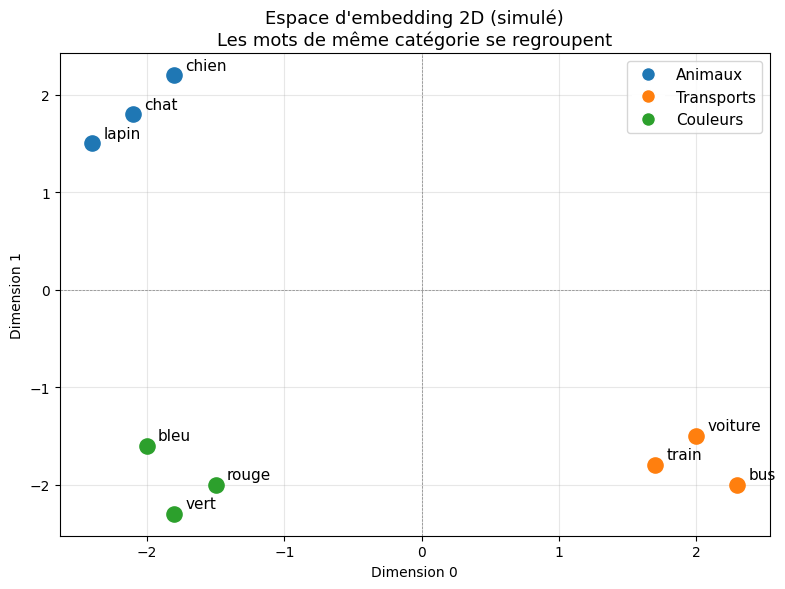

In [8]:
# Vocabulaire étendu avec des mots groupés par sens
mots = ["chat", "chien", "lapin",    # animaux domestiques
        "voiture", "bus", "train",   # transports
        "rouge", "bleu", "vert"]     # couleurs

# Embeddings simulés en 2D (pour pouvoir les afficher facilement)
# En réalité d_model serait bien plus grand (ex: 512)
embeddings_2d = torch.tensor([
    # animaux : regroupés en haut à gauche
    [-2.1,  1.8],   # chat
    [-1.8,  2.2],   # chien
    [-2.4,  1.5],   # lapin
    # transports : regroupés en bas à droite
    [ 2.0, -1.5],   # voiture
    [ 2.3, -2.0],   # bus
    [ 1.7, -1.8],   # train
    # couleurs : regroupées en bas à gauche
    [-1.5, -2.0],   # rouge
    [-2.0, -1.6],   # bleu
    [-1.8, -2.3],   # vert
])

# Visualisation
couleurs = ["tab:blue"] * 3 + ["tab:orange"] * 3 + ["tab:green"] * 3
groupes  = ["Animaux"] * 3 + ["Transports"] * 3 + ["Couleurs"] * 3

fig, ax = plt.subplots(figsize=(8, 6))

for i, (mot, (x_val, y_val), couleur) in enumerate(zip(mots, embeddings_2d, couleurs)):
    ax.scatter(x_val, y_val, color=couleur, s=120, zorder=3)
    ax.annotate(mot, (x_val, y_val), textcoords="offset points",
                xytext=(8, 4), fontsize=11)

# Légende manuelle
from matplotlib.lines import Line2D
legende = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue',   markersize=10, label='Animaux'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', markersize=10, label='Transports'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green',  markersize=10, label='Couleurs'),
]
ax.legend(handles=legende, fontsize=11)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title("Espace d'embedding 2D (simulé)\nLes mots de même catégorie se regroupent", fontsize=13)
ax.set_xlabel("Dimension 0")
ax.set_ylabel("Dimension 1")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Après entraînement, les mots sémantiquement proches (animaux, transports, couleurs) se regroupent naturellement dans l'espace vectoriel. Le réseau apprend ces relations **sans supervision explicite** sur les catégories.

---

## 3. Positional Encoding

### 3.1 Le problème de l'ordre dans le Transformer

Le mécanisme d'attention (que nous verrons dans le prochain notebook) compare **tous les tokens entre eux simultanément**.  
Contrairement aux RNNs, il n'y a pas de traitement séquentiel.  

Conséquence : **le Transformer est insensible à l'ordre des mots** !

```
"le chat mange le poisson"  ←→  "le poisson mange le chat"
        ↓  (sans positional encoding)
  Même représentation ! ← Problème
```

**Solution :** Ajouter un vecteur qui encode la **position** de chaque token dans la séquence.

### 3.2 Formule du Positional Encoding (Vaswani et al., 2017)

L'article original "Attention Is All You Need" propose une fonction sinusoïdale :

$$PE_{(pos,\, 2i)} = \sin\left(\frac{pos}{10000^{\,2i/d_{model}}}\right)$$

$$PE_{(pos,\, 2i+1)} = \cos\left(\frac{pos}{10000^{\,2i/d_{model}}}\right)$$

Où :
- `pos` = position du token dans la séquence (0, 1, 2, ...)
- `i` = indice de la dimension (0, 1, 2, ..., d_model/2 - 1)
- `d_model` = dimension de l'embedding

**Pourquoi des sinusoïdes ?**
- Les fréquences varient selon la dimension → chaque position a un "code" unique
- Le modèle peut apprendre à calculer des positions relatives facilement
- Fonctionne pour des séquences plus longues que celles vues à l'entraînement

### 3.3 Implémentation du Positional Encoding

In [9]:
def positional_encoding(seq_len, d_model):
    """
    Calcule la matrice de positional encoding.

    Paramètres :
        seq_len  : longueur de la séquence
        d_model  : dimension de l'embedding

    Retourne :
        PE : tenseur de shape (seq_len, d_model)
    """
    PE = torch.zeros(seq_len, d_model)

    # Vecteur des positions : shape (seq_len, 1)
    positions = torch.arange(seq_len, dtype=torch.float).unsqueeze(1)

    # Indices des dimensions paires : 0, 2, 4, ...
    dims_pairs = torch.arange(0, d_model, 2, dtype=torch.float)

    # Terme diviseur : 10000^(2i/d_model)
    div_term = 10000.0 ** (dims_pairs / d_model)

    # Dimensions paires  → sinus
    PE[:, 0::2] = torch.sin(positions / div_term)

    # Dimensions impaires → cosinus
    PE[:, 1::2] = torch.cos(positions / div_term)

    return PE


# Test avec notre exemple
seq_len = 3
d_model = 4
PE = positional_encoding(seq_len, d_model)

print(f"Positional Encoding pour seq_len={seq_len}, d_model={d_model} :")
print(PE)
print(f"\nShape : {PE.shape}   →   (seq_len={seq_len}, d_model={d_model})")

Positional Encoding pour seq_len=3, d_model=4 :
tensor([[ 0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.0100,  0.9999],
        [ 0.9093, -0.4161,  0.0200,  0.9998]])

Shape : torch.Size([3, 4])   →   (seq_len=3, d_model=4)


### 3.4 Visualisation — La heatmap du Positional Encoding

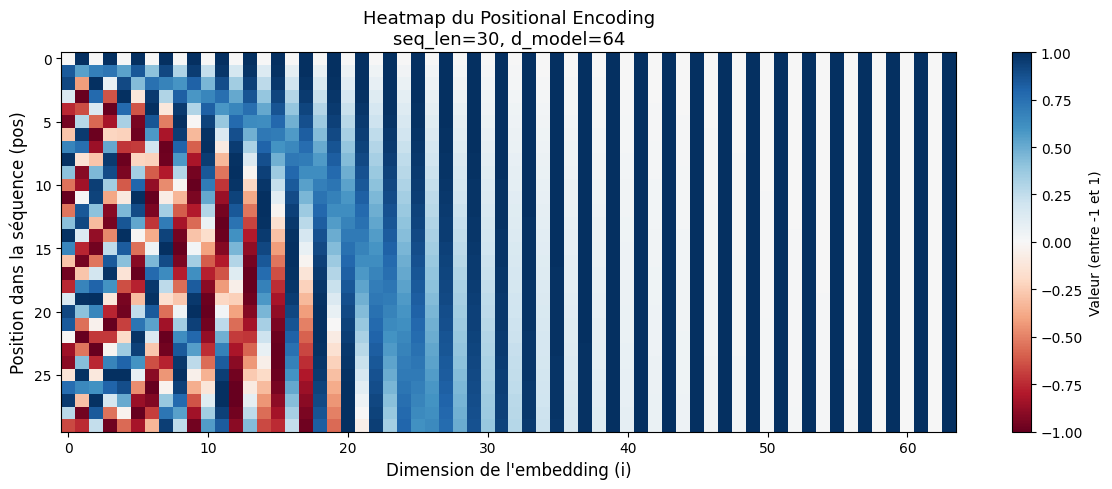

Observations :
• Les dimensions de GAUCHE oscillent vite (haute fréquence)
  → elles discriminent les positions PROCHES (court terme)

• Les dimensions de DROITE semblent uniformes sur 50 positions.
  Ce n'est pas une erreur — c'est intentionnel !

  Explication : pour d_model=64, la dernière dimension a un div_term ≈ 7 197
  → période = 2π × 7197 ≈ 45 000 positions
  Sur 50 positions, elle n'a parcouru que 1/900e de son cycle.
  Elle semble constante, mais ses valeurs varient légèrement.

• Les dimensions de droite → discriminent les positions LOINTAINES (long terme)
  (utiles pour des séquences de plusieurs milliers de tokens)

  Analogie : une horloge
    aiguille des secondes (dim gauches) → discrimine 0-59s
    aiguille des heures   (dim droites) → ne sert qu'à l'échelle de la journée

• Chaque ligne EST mathématiquement unique, mais les dim. droites
  ne montrent cette unicité qu'à très grande échelle.


In [ ]:
# Visualisation sur une séquence plus longue pour voir les patterns
seq_len_visu  = 50
d_model_visu  = 64
PE_visu = positional_encoding(seq_len_visu, d_model_visu)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(PE_visu.numpy(), aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Valeur (entre -1 et 1)')

ax.set_xlabel("Dimension de l'embedding (i)", fontsize=12)
ax.set_ylabel("Position dans la séquence (pos)", fontsize=12)
ax.set_title(f"Heatmap du Positional Encoding\n"
             f"seq_len={seq_len_visu}, d_model={d_model_visu}", fontsize=13)

plt.tight_layout()
plt.show()

print("Observations :")
print("• Les dimensions de GAUCHE oscillent vite (haute fréquence)")
print("  → elles discriminent les positions PROCHES (court terme)")
print()
print("• Les dimensions de DROITE semblent uniformes sur 50 positions.")
print("  Ce n'est pas une erreur — c'est intentionnel !")
print()
print("  Explication : pour d_model=64, la dernière dimension a un div_term ≈ 7 197")
print("  → période = 2π × 7197 ≈ 45 000 positions")
print("  Sur 50 positions, elle n'a parcouru que 1/900e de son cycle.")
print("  Elle semble constante, mais ses valeurs varient légèrement.")
print()
print("• Les dimensions de droite → discriminent les positions LOINTAINES (long terme)")
print("  (utiles pour des séquences de plusieurs milliers de tokens)")
print()
print("  Analogie : une horloge")
print("    aiguille des secondes (dim gauches) → discrimine 0-59s")
print("    aiguille des heures   (dim droites) → ne sert qu'à l'échelle de la journée")
print()
print("• Chaque ligne EST mathématiquement unique, mais les dim. droites")
print("  ne montrent cette unicité qu'à très grande échelle.")

In [11]:
# Vérification : les lignes "uniformes" sont-elles vraiment identiques ?
# On inspecte les valeurs brutes des dimensions droites pour quelques positions

print("Valeurs des 4 dernières dimensions (les plus 'uniformes' visuellement)")
print("pour les positions 0, 10, 20, 30, 40, 49 :\n")
print(f"{'pos':>4}  {'dim 60':>10}  {'dim 61':>10}  {'dim 62':>10}  {'dim 63':>10}")
print("-" * 52)
for pos in [0, 10, 20, 30, 40, 49]:
    vals = PE_visu[pos, -4:].tolist()
    print(f"{pos:>4}  {vals[0]:>10.6f}  {vals[1]:>10.6f}  {vals[2]:>10.6f}  {vals[3]:>10.6f}")

print()
print("→ Les valeurs varient bien, mais de l'ordre de 0.001 — imperceptible sur la heatmap.")
print()

# Vérification mathématique : aucune ligne ne se répète
nb_lignes_uniques = len(set(map(tuple, PE_visu.numpy().tolist())))
print(f"Nombre de lignes uniques sur {seq_len_visu} positions : {nb_lignes_uniques}")
print("→ Chaque position a bien une signature vectorielle distincte.")

Valeurs des 4 dernières dimensions (les plus 'uniformes' visuellement)
pour les positions 0, 10, 20, 30, 40, 49 :

 pos      dim 60      dim 61      dim 62      dim 63
----------------------------------------------------
   0    0.000000    1.000000    0.000000    1.000000
  10    0.001778    0.999998    0.001334    0.999999
  20    0.003557    0.999994    0.002667    0.999996
  30    0.005335    0.999986    0.004001    0.999992
  40    0.007113    0.999975    0.005334    0.999986
  49    0.008713    0.999962    0.006534    0.999979

→ Les valeurs varient bien, mais de l'ordre de 0.001 — imperceptible sur la heatmap.

Nombre de lignes uniques sur 50 positions : 50
→ Chaque position a bien une signature vectorielle distincte.


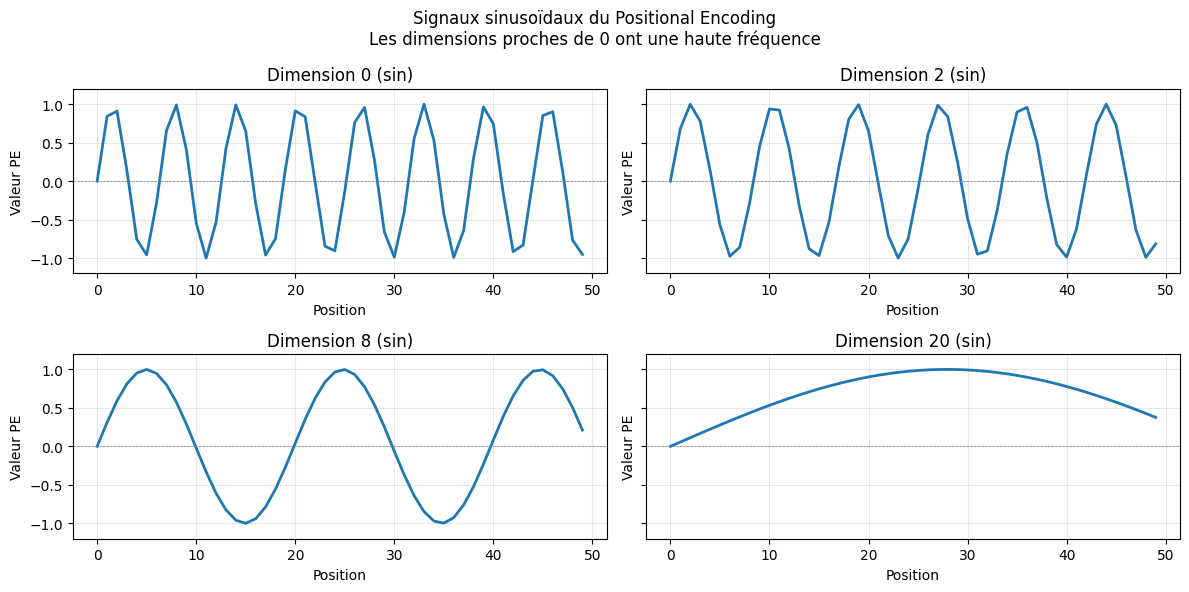

In [12]:
# Visualisation complémentaire : les sinusoïdes pour quelques dimensions
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharey=True)

dims_a_montrer = [0, 2, 8, 20]  # quelques indices de dimensions
positions_range = np.arange(seq_len_visu)

for ax, dim in zip(axes.flat, dims_a_montrer):
    valeurs = PE_visu[:, dim].numpy()
    ax.plot(positions_range, valeurs, linewidth=2)
    ax.set_title(f"Dimension {dim} ({'sin' if dim % 2 == 0 else 'cos'})")
    ax.set_xlabel("Position")
    ax.set_ylabel("Valeur PE")
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.2, 1.2)

fig.suptitle("Signaux sinusoïdaux du Positional Encoding\n"
             "Les dimensions proches de 0 ont une haute fréquence", fontsize=12)
plt.tight_layout()
plt.show()

---

## 4. Combinaison finale : Token Embedding + Positional Encoding

La sortie de la couche d'embedding du Transformer est simplement la **somme** des deux :

$$\text{Entrée}_{\text{Transformer}} = \text{TokenEmbedding}(x) + PE$$

Les deux matrices ont la même forme `(seq_len, d_model)` → la somme est directe.

> **Pourquoi additionner plutôt que concaténer ?**  
> Concaténer doublerait la dimension. L'addition préserve `d_model` et permet au modèle d'apprendre à séparer les deux informations dans l'espace vectoriel.

In [21]:
# Paramètres
V       = len(vocab)
d_model = 8
phrase  = ["le", "chat", "mange"]
seq_len = len(phrase)
indices = torch.tensor([vocab[mot] for mot in phrase])

# 1. Token Embedding
couche_embedding = nn.Embedding(num_embeddings=V, embedding_dim=d_model)
token_emb = couche_embedding(indices)          # shape: (seq_len, d_model)

# 2. Positional Encoding
pos_enc = positional_encoding(seq_len, d_model)  # shape: (seq_len, d_model)

# 3. Combinaison
embedding_final = token_emb + pos_enc             # shape: (seq_len, d_model)

print(f"Token Embedding   shape : {token_emb.shape}")
print(f"Positional Enc.   shape : {pos_enc.shape}")
print(f"Embedding final   shape : {embedding_final.shape}")
print()
print("Embedding final (entrée du Transformer) :")
print(embedding_final.detach())

Token Embedding   shape : torch.Size([3, 8])
Positional Enc.   shape : torch.Size([3, 8])
Embedding final   shape : torch.Size([3, 8])

Embedding final (entrée du Transformer) :
tensor([[ 0.0358,  1.1206, -0.8057,  0.7924, -0.9319, -0.5910, -1.1360,  0.4774],
        [ 0.3227, -0.9610, -1.8268,  1.1229,  1.0329,  0.4442,  0.7053,  1.7099],
        [ 2.6837, -1.3377,  1.1611,  0.6431, -1.1553,  1.3579,  0.4808,  2.3537]])


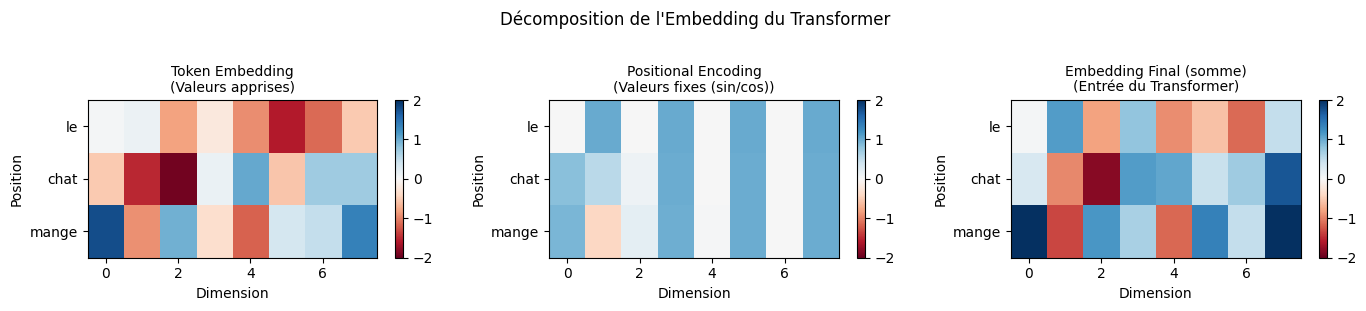

In [22]:
# Visualisation des 3 composantes
fig, axes = plt.subplots(1, 3, figsize=(14, 3))

donnees = [
    (token_emb.detach().numpy(),   "Token Embedding",    "Valeurs apprises"),
    (pos_enc.numpy(),              "Positional Encoding","Valeurs fixes (sin/cos)"),
    (embedding_final.detach().numpy(), "Embedding Final (somme)", "Entrée du Transformer"),
]

for ax, (data, titre, sous_titre) in zip(axes, donnees):
    im = ax.imshow(data, aspect='auto', cmap='RdBu', vmin=-2, vmax=2)
    ax.set_title(f"{titre}\n({sous_titre})", fontsize=10)
    ax.set_xlabel("Dimension")
    ax.set_ylabel("Position")
    ax.set_yticks(range(seq_len))
    ax.set_yticklabels(phrase)
    plt.colorbar(im, ax=ax)

plt.suptitle("Décomposition de l'Embedding du Transformer", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# Paramètres
V       = len(vocab)
d_model = 8
phrase  = ["mange", "le", "chat"]
seq_len = len(phrase)
indices = torch.tensor([vocab[mot] for mot in phrase])

# 1. Token Embedding
token_emb = couche_embedding(indices)          # shape: (seq_len, d_model)

# 2. Positional Encoding
pos_enc = positional_encoding(seq_len, d_model)  # shape: (seq_len, d_model)

# 3. Combinaison
embedding_final = token_emb + pos_enc             # shape: (seq_len, d_model)

print(f"Token Embedding   shape : {token_emb.shape}")
print(f"Positional Enc.   shape : {pos_enc.shape}")
print(f"Embedding final   shape : {embedding_final.shape}")
print()
print("Embedding final (entrée du Transformer) :")
print(embedding_final.detach())

Token Embedding   shape : torch.Size([3, 8])
Positional Enc.   shape : torch.Size([3, 8])
Embedding final   shape : torch.Size([3, 8])

Embedding final (entrée du Transformer) :
tensor([[ 1.7744,  0.0784,  0.9624,  0.6630, -1.1753,  1.3581,  0.4788,  2.3537],
        [ 0.8773,  0.6609, -0.7058,  0.7874, -0.9219, -0.5910, -1.1350,  0.4774],
        [ 0.3905, -1.9174, -1.7280,  1.1079,  1.0429,  0.4440,  0.7063,  1.7099]])


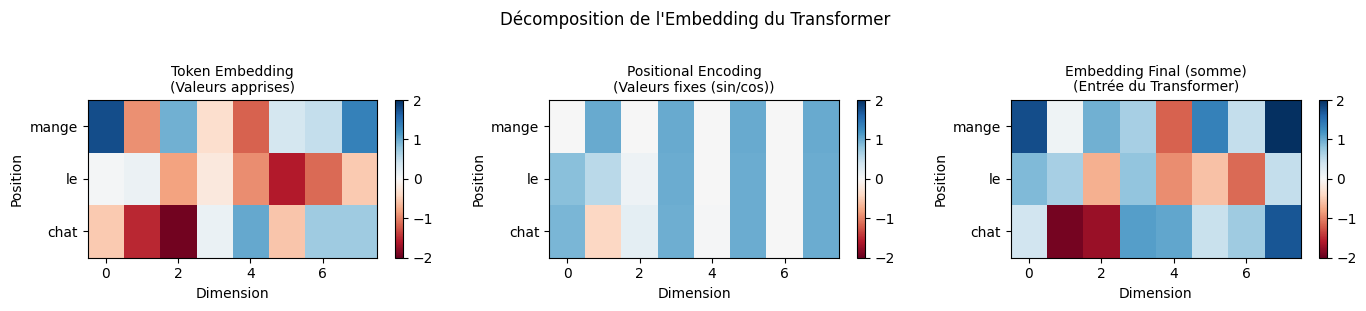

In [26]:
# Visualisation des 3 composantes
fig, axes = plt.subplots(1, 3, figsize=(14, 3))

donnees = [
    (token_emb.detach().numpy(),   "Token Embedding",    "Valeurs apprises"),
    (pos_enc.numpy(),              "Positional Encoding","Valeurs fixes (sin/cos)"),
    (embedding_final.detach().numpy(), "Embedding Final (somme)", "Entrée du Transformer"),
]

for ax, (data, titre, sous_titre) in zip(axes, donnees):
    im = ax.imshow(data, aspect='auto', cmap='RdBu', vmin=-2, vmax=2)
    ax.set_title(f"{titre}\n({sous_titre})", fontsize=10)
    ax.set_xlabel("Dimension")
    ax.set_ylabel("Position")
    ax.set_yticks(range(seq_len))
    ax.set_yticklabels(phrase)
    plt.colorbar(im, ax=ax)

plt.suptitle("Décomposition de l'Embedding du Transformer", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---

## 5. Résumé de la couche Embedding

```
Phrase : ["le", "chat", "mange"]
           ↓
       Tokenisation
           ↓
Indices : [0, 1, 2]
           ↓
   ┌─────────────────┐       ┌──────────────────────┐
   │  nn.Embedding   │       │  positional_encoding │
   │  (V, d_model)   │       │  (seq_len, d_model)  │
   └────────┬────────┘       └──────────┬───────────┘
            │    (appris)          (fixe ou appris)
            └───────────┬────────────┘
                        ↓
                      Somme
                        ↓
          Embedding final (seq_len, d_model)
                        ↓
              Couche d'Attention →
```

| Composante | Shape | Paramètres |
|---|---|---|
| Token Embedding | `(seq_len, d_model)` | `V × d_model` (appris) |
| Positional Encoding | `(seq_len, d_model)` | 0 (calculé, fixe) |
| **Embedding final** | **`(seq_len, d_model)`** | — |

Dans le prochain notebook, nous utiliserons cet embedding final comme entrée du mécanisme d'**attention**.